#  Assignment No. 7b

###  Title: Implementation of K-Means Clustering using R
###  Dataset: iris (built-in)

# 1. Install & Load Libraries

In [1]:
if (!require(ggplot2))     install.packages("ggplot2",     repos="https://cran.r-project.org")
if (!require(cluster))     install.packages("cluster",     repos="https://cran.r-project.org")
if (!require(factoextra))  install.packages("factoextra",  repos="https://cran.r-project.org")
if (!require(gridExtra))   install.packages("gridExtra",   repos="https://cran.r-project.org")

library(ggplot2)
library(cluster)
library(factoextra)
library(gridExtra)

Loading required package: ggplot2

Loading required package: cluster

Loading required package: factoextra

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘factoextra’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’


Loading required package: gridExtra

Welcome to fa

# 2. Load & Explore Dataset

In [2]:
data(iris)
dataset <- iris

cat("===== Dataset Overview =====\n")
cat("Rows:", nrow(dataset), "| Columns:", ncol(dataset), "\n")
str(dataset)
cat("\n")
print(summary(dataset))

# Remove the Species label – K-Means is unsupervised
iris_features <- dataset[, 1:4]

# Standardize features
iris_scaled <- scale(iris_features)
cat("\n===== Scaled Data (first 5 rows) =====\n")
print(head(iris_scaled))

===== Dataset Overview =====
Rows: 150 | Columns: 5 
'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
     

# 3. Elbow Method – Determine Optimal k


===== Elbow Method =====
    k       WSS
1   1 596.00000
2   2 220.87929
3   3 138.88836
4   4 113.33162
5   5  90.20221
6   6  80.10378
7   7  70.18758
8   8  63.36061
9   9  53.80468
10 10  46.84282


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


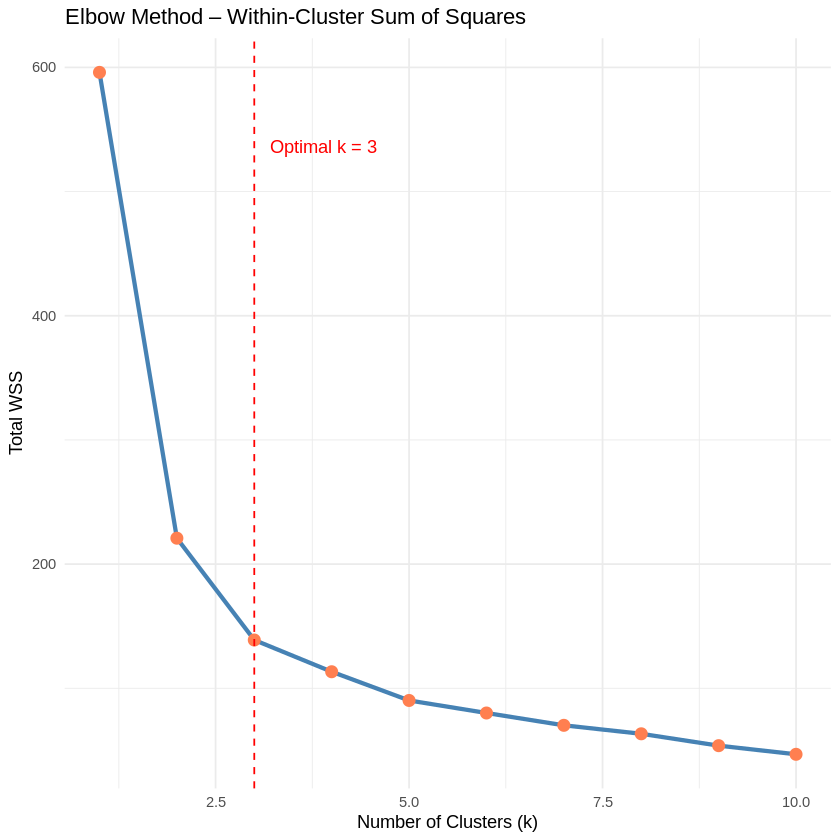

In [3]:
cat("\n===== Elbow Method =====\n")
set.seed(42)
wss <- sapply(1:10, function(k) {
  kmeans(iris_scaled, centers = k, nstart = 25, iter.max = 100)$tot.withinss
})

elbow_df <- data.frame(k = 1:10, WSS = wss)
print(elbow_df)

ggplot(elbow_df, aes(x = k, y = WSS)) +
  geom_line(color = "steelblue", size = 1.2) +
  geom_point(color = "coral",    size = 3) +
  geom_vline(xintercept = 3, linetype = "dashed", color = "red") +
  annotate("text", x = 3.2, y = max(wss) * 0.9,
           label = "Optimal k = 3", color = "red", hjust = 0) +
  labs(title = "Elbow Method – Within-Cluster Sum of Squares",
       x     = "Number of Clusters (k)",
       y     = "Total WSS") +
  theme_minimal()

# 4. Silhouette Method – Confirm k

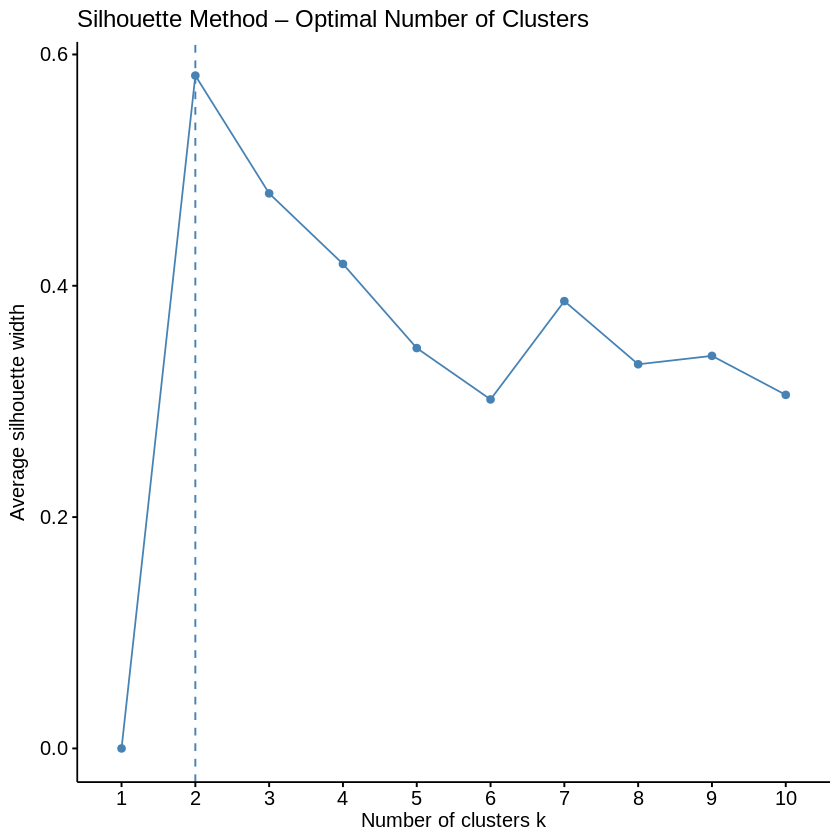

In [4]:
fviz_nbclust(iris_scaled, kmeans, method = "silhouette") +
  labs(title = "Silhouette Method – Optimal Number of Clusters")

# 5. Apply K-Means with Optimal k = 3

In [5]:
set.seed(42)
k_optimal <- 3
kmeans_model <- kmeans(iris_scaled,
                       centers   = k_optimal,
                       nstart    = 25,
                       iter.max  = 100,
                       algorithm = "Hartigan-Wong")

cat("\n===== K-Means Model Summary =====\n")
cat("Number of clusters   :", kmeans_model$size, "\n")
cat("Total WSS            :", round(kmeans_model$tot.withinss, 4), "\n")
cat("Between-cluster SS   :", round(kmeans_model$betweenss,    4), "\n")
cat("Total SS             :", round(kmeans_model$totss,        4), "\n")
cat("Ratio (BSS/TSS)      :", round(kmeans_model$betweenss / kmeans_model$totss, 4), "\n")

cat("\n===== Cluster Centers (scaled) =====\n")
print(kmeans_model$centers)

cat("\n===== Cluster Sizes =====\n")
print(kmeans_model$size)


===== K-Means Model Summary =====
Number of clusters   : 50 53 47 
Total WSS            : 138.8884 
Between-cluster SS   : 457.1116 
Total SS             : 596 
Ratio (BSS/TSS)      : 0.767 

===== Cluster Centers (scaled) =====
  Sepal.Length Sepal.Width Petal.Length Petal.Width
1  -1.01119138  0.85041372   -1.3006301  -1.2507035
2  -0.05005221 -0.88042696    0.3465767   0.2805873
3   1.13217737  0.08812645    0.9928284   1.0141287

===== Cluster Sizes =====
[1] 50 53 47


# 6. Add Cluster Labels to Dataset

In [6]:
dataset$Cluster <- as.factor(kmeans_model$cluster)

cat("\n===== Cluster vs Actual Species Comparison =====\n")
print(table(Cluster = dataset$Cluster, Species = dataset$Species))


===== Cluster vs Actual Species Comparison =====
       Species
Cluster setosa versicolor virginica
      1     50          0         0
      2      0         39        14
      3      0         11        36


# 7. Visualization

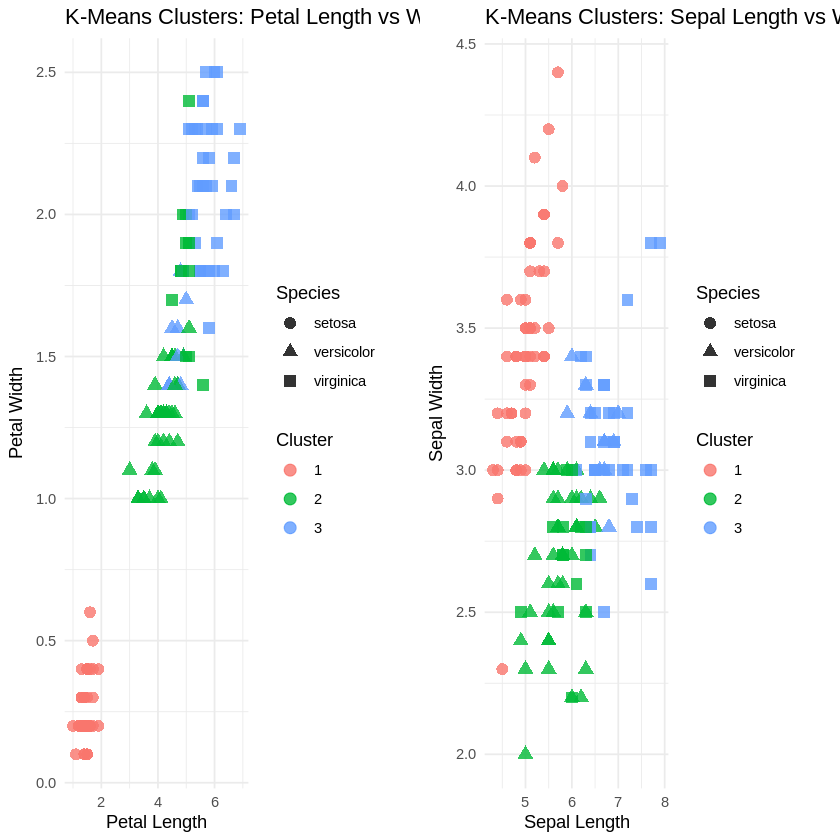

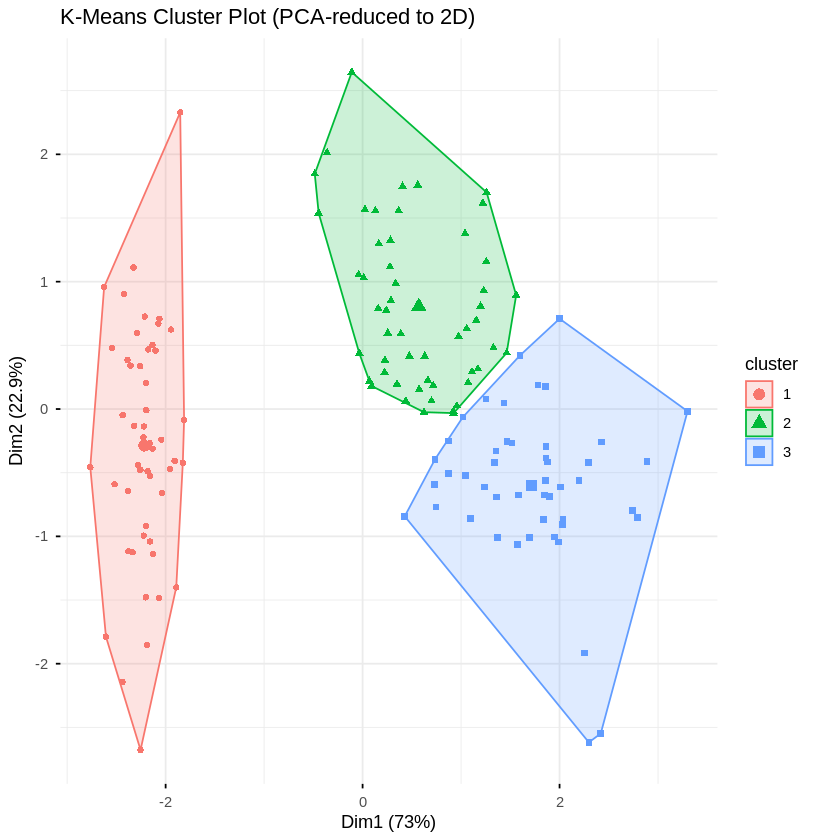

In [7]:
p1 <- ggplot(dataset, aes(x = Petal.Length, y = Petal.Width,
                           color = Cluster, shape = Species)) +
  geom_point(size = 3, alpha = 0.8) +
  labs(title = "K-Means Clusters: Petal Length vs Width",
       x = "Petal Length", y = "Petal Width") +
  theme_minimal()

# Plot 2: Clusters on Sepal dimensions
p2 <- ggplot(dataset, aes(x = Sepal.Length, y = Sepal.Width,
                           color = Cluster, shape = Species)) +
  geom_point(size = 3, alpha = 0.8) +
  labs(title = "K-Means Clusters: Sepal Length vs Width",
       x = "Sepal Length", y = "Sepal Width") +
  theme_minimal()

grid.arrange(p1, p2, ncol = 2)

# Plot 3: PCA-reduced 2D visualization using factoextra
fviz_cluster(kmeans_model,
             data        = iris_scaled,
             geom        = "point",
             ellipse.type = "convex",
             ggtheme     = theme_minimal(),
             main        = "K-Means Cluster Plot (PCA-reduced to 2D)")

# 8. Silhouette Plot for k=3

  cluster size ave.sil.width
1       1   50          0.64
2       2   53          0.39
3       3   47          0.35

===== Average Silhouette Width =====
0.4599 
(Values close to 1 indicate well-separated clusters)


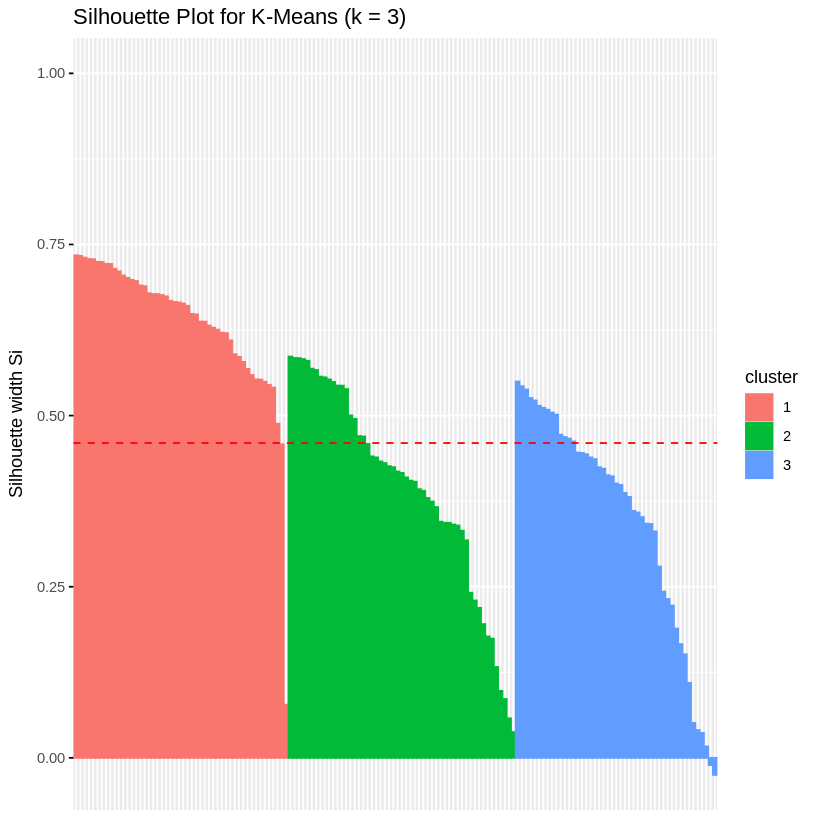

In [8]:
sil <- silhouette(kmeans_model$cluster, dist(iris_scaled))
fviz_silhouette(sil,
                main = "Silhouette Plot for K-Means (k = 3)")

cat("\n===== Average Silhouette Width =====\n")
cat(round(mean(sil[, 3]), 4), "\n")
cat("(Values close to 1 indicate well-separated clusters)\n")

# 9. Compare Different k values

In [9]:
cat("\n===== Accuracy-like Comparison (Adjusted Rand Index) =====\n")
if (!require(mclust)) install.packages("mclust", repos="https://cran.r-project.org")
library(mclust)

true_labels <- as.integer(iris$Species)
for (k in 2:5) {
  set.seed(42)
  km  <- kmeans(iris_scaled, centers = k, nstart = 25)
  ari <- adjustedRandIndex(km$cluster, true_labels)
  cat(sprintf("k = %d : Adjusted Rand Index = %.4f\n", k, ari))
}


===== Accuracy-like Comparison (Adjusted Rand Index) =====


Loading required package: mclust

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘mclust’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



k = 2 : Adjusted Rand Index = 0.5681
k = 3 : Adjusted Rand Index = 0.6201
k = 4 : Adjusted Rand Index = 0.4706
k = 5 : Adjusted Rand Index = 0.4181
